In [28]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal



In [29]:
class QuadraticState(TypedDict):
    a: float
    b: float
    c: float
    
    equation: str
    discriminant: float
    results : str

In [30]:
def show_equation(state:QuadraticState):
    a = state["a"]
    b = state["b"]
    c = state["c"]
    equation  = f"{a}x^2 + {b}x + {c} = 0"
    return {"equation": equation}

In [31]:
def calculate_discriminant(state:QuadraticState):
    a = state["a"]
    b = state["b"]
    c = state["c"]
    discriminant = b**2 - 4*a*c
    return {"discriminant": discriminant}

In [32]:
def real_root(state:QuadraticState):
    a = state["a"]
    b = state["b"]
    c = state["c"]
    D = state["discriminant"]
    root1 = (-b + D**0.5) / (2*a)
    root2 = (-b - D**0.5) / (2*a)
    results = f"Real roots: {root1}, {root2}"
    return {"results": results}

In [33]:
def repeated_root(state:QuadraticState):
    a = state["a"]
    b = state["b"]
    root = -b / (2*a)
    results = f"Repeated root: {root}"
    return {"results": results}

In [34]:
def no_real_root(state:QuadraticState):
    results = "No real roots"
    return {"results": results}

In [35]:
def check_discriminant(state:QuadraticState) -> Literal["real_root","repeated_root","no_real_root"]:
    D = state["discriminant"]
    if D > 0:
        return "real_root"
    elif D == 0:
        return "repeated_root"
    else:
        return "no_real_root"

In [36]:
graph = StateGraph(QuadraticState)

graph.add_node("show_equation",show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)
graph.add_node("real_root",real_root)
graph.add_node("repeated_root",repeated_root)
graph.add_node("no_real_root",no_real_root)

graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_discriminant")

graph.add_conditional_edges("calculate_discriminant", check_discriminant)

graph.add_edge("real_root",END)
graph.add_edge("repeated_root",END)
graph.add_edge("no_real_root",END)

In [37]:
workflow = graph.compile()

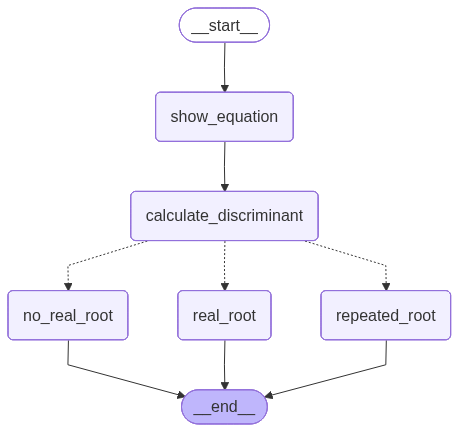

In [38]:
workflow

In [40]:
initial_state = {
    "a": 4,     
    "b": 2,
    "c": 4
}

final_state = workflow.invoke(initial_state)
final_state

{'a': 4,
 'b': 2,
 'c': 4,
 'equation': '4x^2 + 2x + 4 = 0',
 'discriminant': -60,
 'results': 'No real roots'}